In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

def highlight_max(row):
    is_max = row == row.max()
    return ['font-weight: bold' if v else '' for v in is_max]

def drop_nan_group(group):
    if group.isnull().any():
        return None  # Returning None will drop the group
    else:
        return group

def compte_les_points(df):
    results = {}
    total = 0
    for idx, row in df.reset_index()['perf'].iterrows():
        is_max = row == row.max()
        for key in is_max.reset_index()['package'].values:
            if key not in results:
                results[key] = 0
                
            results[key] += int(is_max[key])
        total += 1
            
    for key in results:
        print(f"{key} : {results[key]} / {total}")

In [ ]:
# Load bench 
naive = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/bench/bench_naive.csv")
naive['package'] = 'NaiveAutoML'

iaml = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/bench/bench_iaml.csv")
iaml['package'] = 'IAML'

iaml21 = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/bench/bench_iaml2_1.csv")
iaml21['package'] = 'IAML21'

iaml22 = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/bench/bench_iaml2_2.csv")
iaml22['package'] = 'IAML22'

iaml23 = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/bench/bench_iaml2_3.csv")
iaml23['package'] = 'IAML23'

iaml_void = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/bench/bench_iaml_void_step.csv")
iaml_void['package'] = 'IAML_void'

autosk = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/bench/bench_autosklearn.csv")
autosk['package'] = 'Auto-Sklearn'

merged_df = pd.concat([naive, iaml22, iaml_void, autosk])[['package', 'duration', 'dataset_name', 'perf']]
grouped = merged_df.groupby(['package', 'duration', 'dataset_name']).mean(numeric_only=True).reset_index()

# grouped

In [ ]:
pivot_df = grouped.pivot(index=['dataset_name', 'duration'], columns='package')
pivot_df.style.apply(highlight_max, axis=1)

In [ ]:
# def count(row):
#     is_max = row == row.max()
#     return ['font-weight: bold' if v else '' for v in is_max]

# pivot_df = grouped.pivot(index=['dataset_name', 'duration'], columns='package')

# pivot_df.style.apply(highlight_max, axis=1)

compte_les_points(pivot_df)

In [ ]:
# Auto-Sklearn : 14 / 75
# IAML : 29 / 75
# NaiveAutoML : 38 / 75

In [ ]:
# PAR DATASET sans prendre ne compte le temps
merged_df = pd.concat([naive, iaml22, iaml_void, autosk])[['package', 'duration', 'dataset_name', 'perf']]
# merged_df = pd.concat([naive, iaml, iaml21, iaml22, autosk])[['package', 'duration', 'dataset_name', 'perf']]

merged_df = merged_df.dropna() # Avoid penalize a package if no value

merged_df.drop(columns=['duration'], inplace=True)
grouped = merged_df.groupby(['package', 'dataset_name']).mean(numeric_only=True).reset_index()

pivot_df = grouped.pivot(index=['dataset_name'], columns='package')
pivot_df.style.apply(highlight_max, axis=1)

In [ ]:
compte_les_points(pivot_df)

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

def line_plot(df, filter_tuple, hue="dataset_name",zero_line=False, y_lim=None):
    plt.figure()
    plot = sns.lineplot(data=df[df[filter_tuple[0]] == filter_tuple[1]], x="duration", y="perf", hue=hue) 
    sns.move_legend(plot, "upper left", bbox_to_anchor=(1, 1))
    plt.title(str(filter_tuple))
    if zero_line:
        plt.axhline(y=0.0, color='r', linestyle='--')
        
    if y_lim:
        plt.ylim(*y_lim)
    plt.show()


In [ ]:
line_plot(merged_df, ("package", "IAML_void"))

In [ ]:
line_plot(merged_df, ("package", "NaiveAutoML"))

In [ ]:
line_plot(merged_df, ("package", "Auto-Sklearn"))

In [ ]:
for dataset_name in merged_df['dataset_name'].unique():
    line_plot(merged_df, ("dataset_name", dataset_name), hue="package")

In [ ]:
# Diff with iaml ?
# Ensure df is a copy to avoid SettingWithCopyWarning
df = merged_df.copy()

# Separate 'iaml' and other packages
iaml_df = df[df['package'] == 'IAML_void']
other_df = df[df['package'] != 'IAML_void']

# Average 'iaml' performance for each 'duration' and 'dataset_name' combination
iaml_avg_perf = iaml_df.groupby(['duration', 'dataset_name'])['perf'].mean()

# Merge this average performance back into the other_df based on 'duration' and 'dataset_name'
other_df = other_df.merge(iaml_avg_perf, on=['duration', 'dataset_name'], suffixes=('', '_iaml_avg'))

# Calculate the difference in performance
other_df['perf'] = other_df['perf'] - other_df['perf_iaml_avg']

# Drop the now unnecessary 'perf_iaml_avg' column
other_df.drop(columns=['perf_iaml_avg'], inplace=True)

# Resulting DataFrame has 'iaml' rows removed and 'perf' adjusted
df_result = other_df

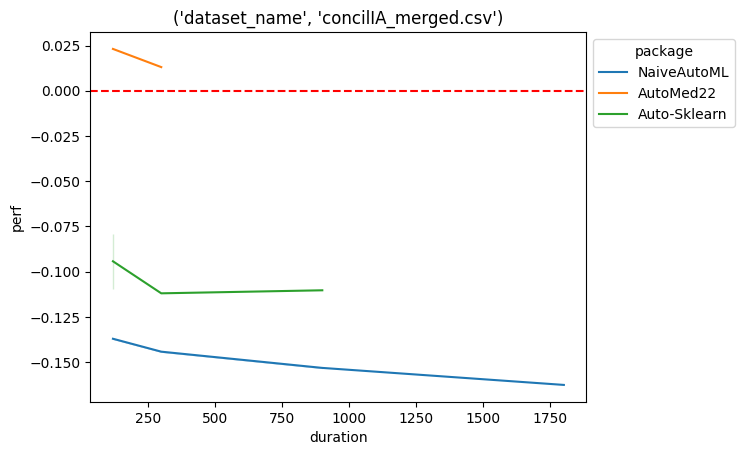

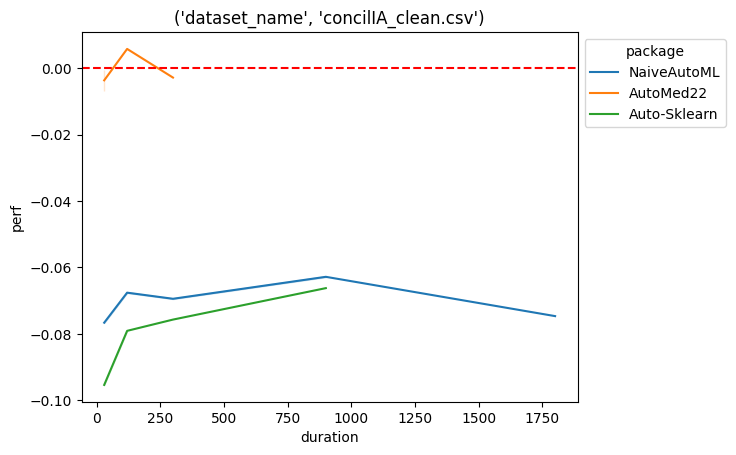

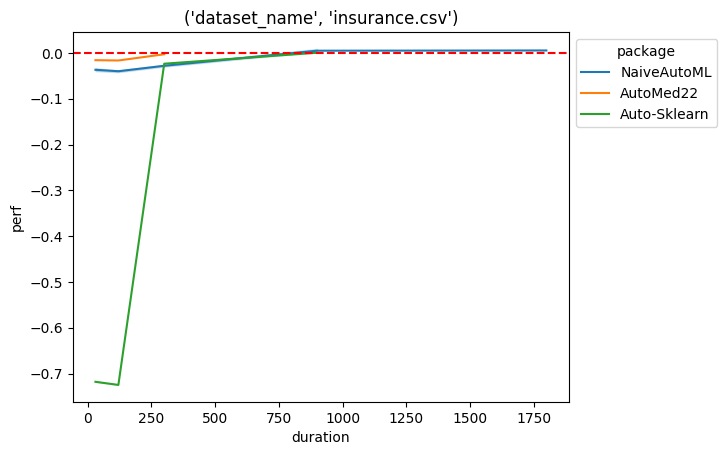

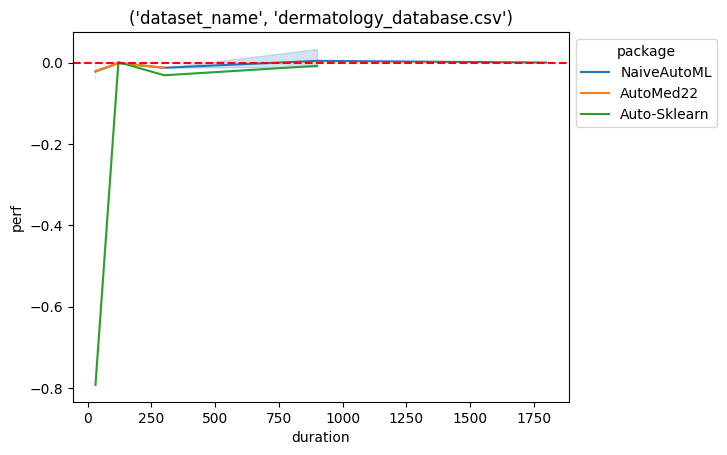

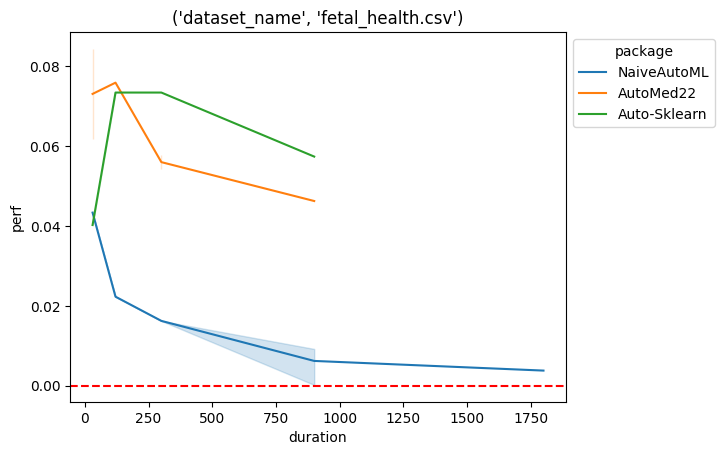

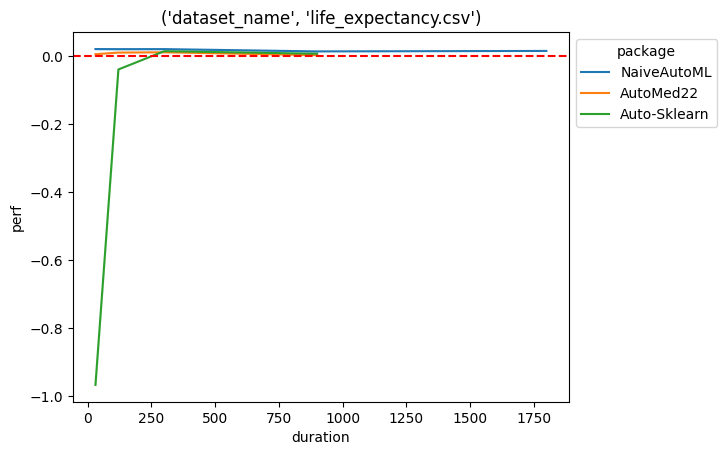

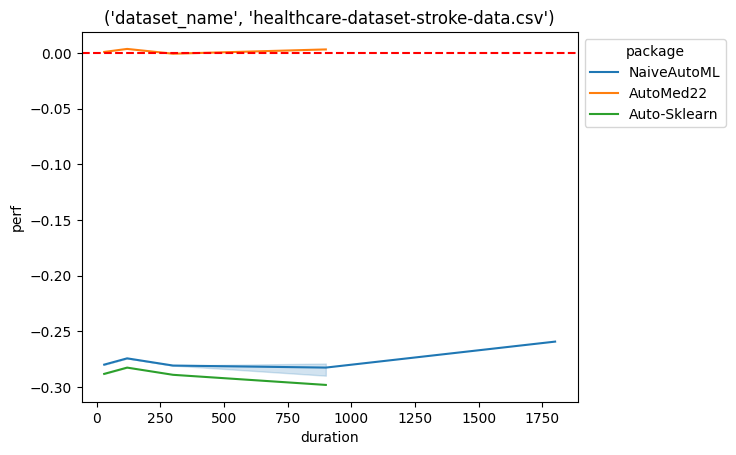

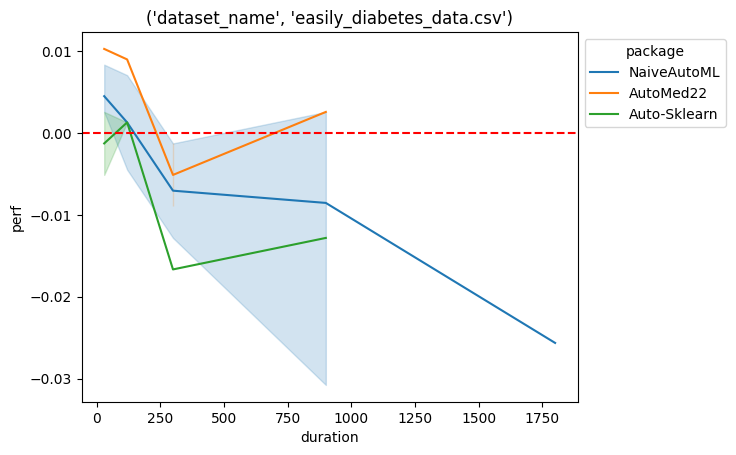

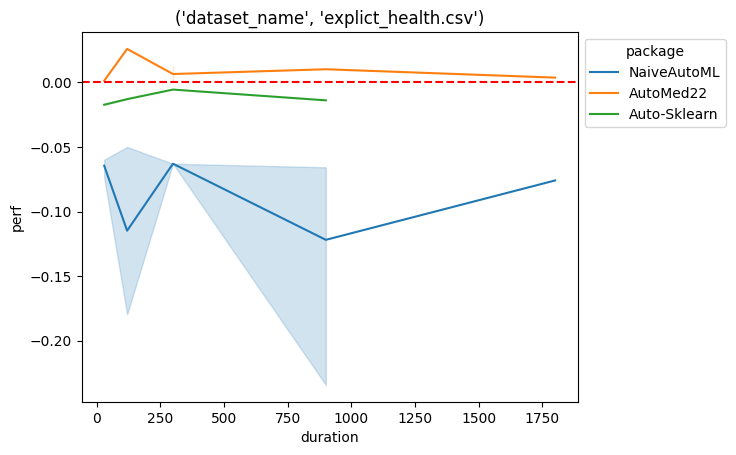

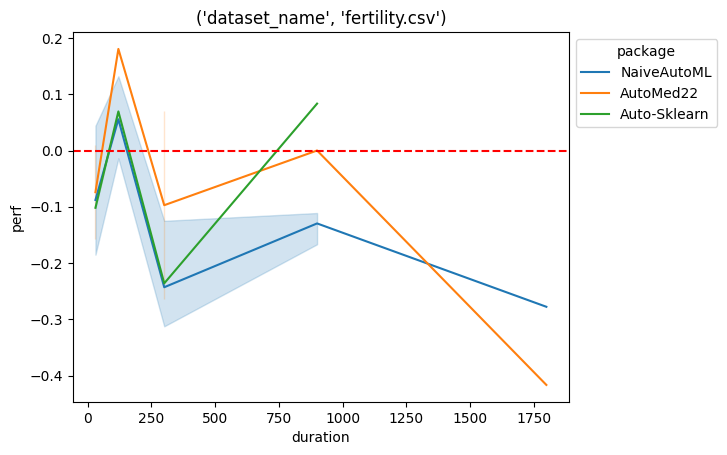

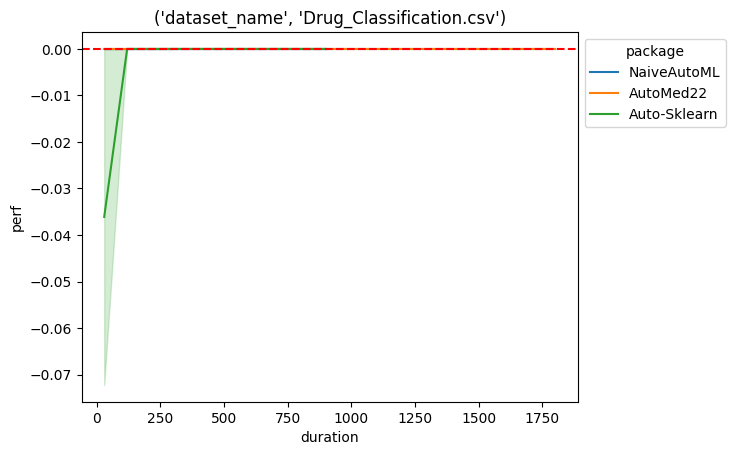

ValueError: Axes(0.125,0.11;0.775x0.77) has no legend attached.

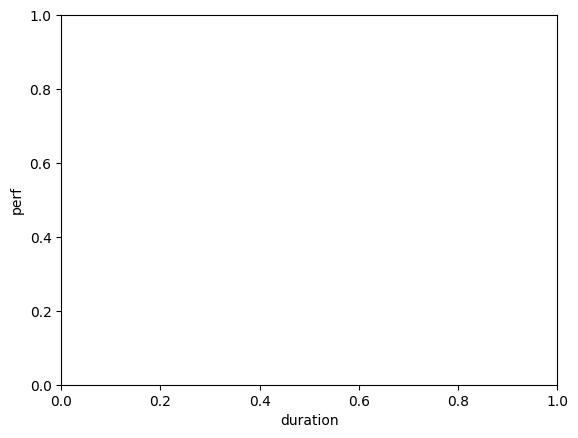

In [49]:
for dataset_name in merged_df['dataset_name'].unique():
    line_plot(df_result, ("dataset_name", dataset_name), hue="package", zero_line=True)